# 🚢 타이타닉 데이터를 학습해 생존/사망 예측

승객 정보(나이·성별·객실 등급 등)를 학습해 **생존(1) / 사망(0)** 을 예측하는 모델을 만든다.

> ⚙️ **아래 코드는 수업 때 작성한 내용 그대로이며, 이해를 돕는 주석과 설명만 추가했습니다.**

**진행 순서**
1. 데이터 불러오기 & 살펴보기
2. 전처리 & EDA (결측치 처리)
3. EDA 시각화
4. 파생 변수 만들기 (Family_group)
5. 학습 데이터 준비 (인코딩)
6. 모델 학습 · 예측 · 평가 (Decision Tree)
7. 앙상블(Ensemble) 모델 — Voting · Bagging · Boosting
8. 하이퍼파라미터 튜닝 (Grid Search)

## 1. 데이터 불러오기 & 살펴보기

In [450]:
# 실습에 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [451]:
# CSV 데이터 불러오기 (index_col: 승객번호 PassengerId를 행 인덱스로 사용)
train = pd.read_csv('./data/train.csv', index_col = 'PassengerId')
test = pd.read_csv('./data/test.csv', index_col = 'PassengerId')

In [452]:
# train 데이터 앞부분 5줄 미리보기 (컬럼 구성 확인)
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [453]:
# 데이터 크기 확인 → (행 개수, 열 개수)
print(train.shape)
print(test.shape)

(891, 11)
(418, 10)


## 2. 데이터 전처리 및 EDA

> **EDA(탐색적 데이터 분석)** : 데이터를 살펴보며 컬럼·자료형·결측치·관계를 파악하는 과정.
> 먼저 `info()` 로 **어디에 결측치가 있는지** 확인한다.

In [454]:
# 컬럼별 개수 / 자료형(Dtype) / 결측치 확인 (Non-Null Count가 전체보다 작으면 결측 존재)
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [455]:
# test 데이터도 동일하게 확인 (Survived 컬럼이 없다 = 우리가 맞힐 값)
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [456]:
train.columns
# Survived: 생존/사망 (0:사망, 1:생존)
# Pclass: 객실의 등급 (1~3, 1:상위층, 2:중상위층, 3:하위층)
# SibSp: 형제자매, 배우자 (같이 탑승한)
# Parch: 부모/자식의 수 (같이 탑승한)
# Ticket: 티켓 번호
# Fare: 요금
# Cabin: 객실 번호
# Embarked: 승선항 (S, C, Q)

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [457]:
# train 결측 데이터: Age, Cabin, Embarked
# test 결측 데이터: Age, Fare, Cabin

# 결측치를 채우는 방법
# 1. 결측 데이터가 있는 행을 삭제한다!
# → 실제 결과에 치명적인 영향을 주지 안주는 데이터

# 2. 결측 데이터를 채운다!
# 평균값, 최빈값, 중앙값 등으로 결측 데이터를 채운다
# 다른 Feature들과 정보 공유를 해서 데이터를 채운다

### 2-1. Embarked 결측치 처리 (train 2개)

가장 많이 나온 값(최빈값 **S**)으로 채운다.

In [458]:
# Embarked 값별 개수 → 최빈값(가장 많은 값) 파악 (S가 가장 많음)
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [459]:
# Embarked 결측치 개수 (2개)
train['Embarked'].isnull().sum()

np.int64(2)

In [460]:
# Embarked가 결측인 행을 직접 확인
train[train['Embarked'].isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [461]:
# name, age 제외 Feature들이 같은 값을 지닌다
# Embarked를 가장 많은 최빈값으로 채워주겠다(S)
# fillna(값) → 값으로 결측 데이터를 채운다
train['Embarked'] = train['Embarked'].fillna('S')

In [462]:
# 결측치가 잘 채워졌는지 info로 재확인
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


### 2-2. Fare 결측치 처리 (test 1개)

어떤 값으로 채울지 정하기 위해, **상관관계**와 **그룹별 통계(Pclass·Sex)** 를 먼저 살펴본다.

In [463]:
# test에서 Fare가 결측인 행 확인 (1개)
test[test['Fare'].isnull()]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [464]:
# test Fare 기초 통계 (평균/중앙값 등)
###########
test['Fare'].describe()

count    417.000000
mean      35.627188
std       55.907576
min        0.000000
25%        7.895800
50%       14.454200
75%       31.500000
max      512.329200
Name: Fare, dtype: float64

In [465]:
# Fare 컬럼이 다른 Feature(컬럼) 들과의 연관관계를 살펴보고 싶다!
test.corr(numeric_only = True) # 숫자로 된 컬럼만
# 상관 계수(correlation): -1 ~ 1까지의 범위 (절대값이 클수록 연관도 높고 작을수록 연관도 없다)

# Fare는 Pclass 연관도 제일 높은 편이구나 (-0.577147: 절대값이 가장 큼)

,Pclass,Age,SibSp,Parch,Fare
Pclass,1.000000,-0.492143,0.001087,0.018721,-0.577147
Age,-0.492143,1.000000,-0.091587,-0.061249,0.337932
SibSp,0.001087,-0.091587,1.000000,0.306895,0.171539
Parch,0.018721,-0.061249,0.306895,1.000000,0.230046
Fare,-0.577147,0.337932,0.171539,0.230046,1.000000


In [466]:
# train Fare 기초 통계
train['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [467]:
# train 전체 컬럼 간 상관계수
train.corr(numeric_only = True)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [468]:
# Fare와 상관관계가 큰 순서대로 정렬 (절댓값 기준)
train.corr(numeric_only=True)['Fare'].abs().sort_values(ascending=False)

Fare        1.000000
Pclass      0.549500
Survived    0.257307
Parch       0.216225
SibSp       0.159651
Age         0.096067
Name: Fare, dtype: float64

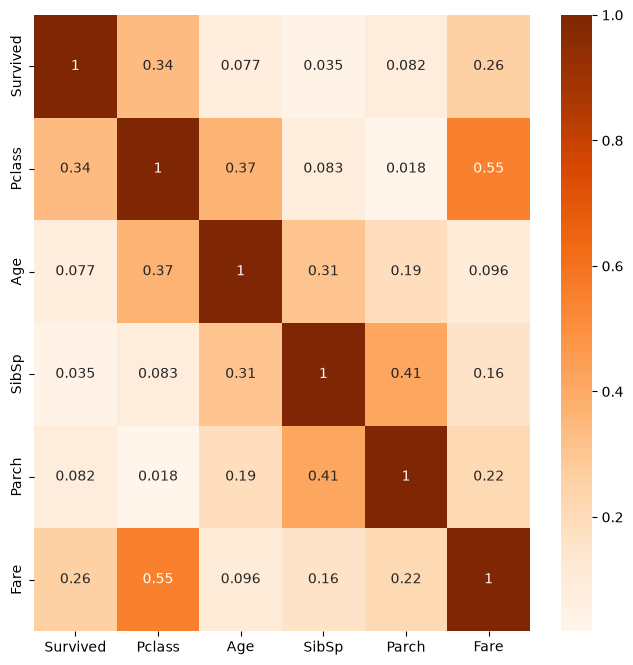

In [469]:
# 시각화 해서 보기
plt.figure(figsize=(8,8))
sns.heatmap(train.corr(numeric_only=True).abs(),annot=True, cmap='Oranges')
# annot: 어노테이션, 레이블
# cmapl: color map
plt.show()

In [470]:
train['Pclass'].unique()
# 1: 상, 2: 중, 3: 하
# 위에서부터 쭉 내려가면서 처음나온거 넣어주는 기능(중복 제거)

array([3, 1, 2])

In [471]:
# Pclass, Fare를 같이 통계 Pclass 각각의 Fare 중앙값 찾기
train[['Pclass','Fare']].groupby('Pclass').median()

,Fare
Pclass,
1,60.2875
2,14.2500
3,8.0500


In [472]:
# 'Pclass', 'Sex' 기준으로 그룹 시켜서 Fare의 중앙값 알아보기
train[['Pclass','Fare','Sex']].groupby(['Pclass','Sex']).median()

Fare
Pclass Sex             
1      female  82.66455
       male    41.26250
2      female  22.00000
       male    13.00000
3      female  12.47500
       male     7.92500

In [473]:
# 값을 채우기 전에 Fare 결측 행을 다시 확인
test[test['Fare'].isnull()]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [474]:
# 결측 승객(3등급 남성)의 Fare를 그룹 중앙값 7.925로 채움
test['Fare'] = test['Fare'].fillna(7.925)

### 2-3. Age 결측치 처리 (train · test)

전체 평균이 아니라 **Pclass·Sex 그룹별 평균 나이**로 더 정교하게 채운다.

In [475]:
## train, test Age Feature 결측치 채우기

In [476]:
# train Age 기초 통계
train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [477]:
# Age를 Pclass, Sex 기준으로
gb1 = train[['Pclass','Sex','Age']].groupby(['Pclass','Sex']).mean()
gb1 # 새로운 Dataframe → Pclass, Sex 해당되는 row(data)의 Age를 평균값으로 채우겠다

Age
Pclass Sex              
1      female  34.611765
       male    41.281386
2      female  28.722973
       male    30.740707
3      female  21.750000
       male    26.507589

In [478]:
# Age가 결측인 행 확인
train[train['Age'].isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...
860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S


In [479]:
# 예) (Pclass=1, Sex=male) 그룹의 평균 나이 꺼내보기
gb1.loc[(1, 'male')]

Age    41.281386
Name: (1, male), dtype: float64

> 🔎 **`fill_age` 함수 설명**
>
> - 한 행(row)씩 보면서 `Age`가 비어 있으면, 그 사람의 **(Pclass, Sex) 그룹 평균 나이(`gb1`)** 로 채운다.
> - 비어 있지 않으면 원래 나이를 그대로 둔다.
> - 뒤에서 `apply(fill_age, axis=1)` 로 **모든 행**에 이 함수를 적용한다.

In [480]:
## Pclass, Sex에 따른 Age 결측치를 채우는 함수
def fill_age(row):
    # 한 줄마다 실행하며 결측치 채우기
    # Pclass, Sex를 gb1에서 값을 찾아서 (평균값)으로 결측치를 채운다
    if np.isnan(row['Age']): # data의 한 줄에 'Age'가 결측치 일 때 실행
        temp = gb1.loc[(row['Pclass'],row['Sex'])]
        return temp
    else:
        return row['Age']

In [481]:
# 현재 Age 컬럼 상태 (결측 포함) 확인
train['Age']

PassengerId
1      22.0
2      38.0
3      26.0
4      35.0
5      35.0
       ... 
887    27.0
888    19.0
889     NaN
890    26.0
891    32.0
Name: Age, Length: 891, dtype: float64

In [482]:
# fill_age 적용 결과 미리보기 (아직 train에 대입 전)
train.apply(fill_age, axis = 1).astype(np.int64)
# axis=1: 열방향, 행단위로
# axis=0: 행방향, 열단위로

C:\Users\smhrd\AppData\Local\Temp\ipykernel_23016\2310128509.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  train.apply(fill_age, axis = 1).astype(np.int64)


PassengerId
1      22
2      38
3      26
4      35
5      35
       ..
887    27
888    19
889    21
890    26
891    32
Length: 891, dtype: int64

In [483]:
# 실제로 train['Age']에 대입 (결측치를 채우고 정수형으로 변환)
train['Age'] = train.apply(fill_age, axis = 1).astype(np.int64)

C:\Users\smhrd\AppData\Local\Temp\ipykernel_23016\2233501547.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  train['Age'] = train.apply(fill_age, axis = 1).astype(np.int64)


In [484]:
# train Age 결측이 채워졌는지 확인
train['Age'].info()

<class 'pandas.core.series.Series'>
Index: 891 entries, 1 to 891
Series name: Age
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 13.9 KB


In [485]:
# test 데이터에도 train처럼 'Age' 결측치를 채운다 (fill_age를 통해서)
test['Age'] = test.apply(fill_age, axis=1).astype(np.int64)
test['Age'].info()

<class 'pandas.core.series.Series'>
Index: 418 entries, 892 to 1309
Series name: Age
Non-Null Count  Dtype
--------------  -----
418 non-null    int64
dtypes: int64(1)
memory usage: 6.5 KB


C:\Users\smhrd\AppData\Local\Temp\ipykernel_23016\2013741464.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  test['Age'] = test.apply(fill_age, axis=1).astype(np.int64)


### 2-4. Cabin → Deck (객실 → 갑판)

Cabin은 결측이 너무 많음 → 임의값 **'M'** 으로 채운 뒤 **첫 알파벳(Deck)** 만 뽑아 활용하고, 원본 Cabin은 삭제.

In [486]:
## train, test의 'Cabin' 결측치 채우기
train['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [487]:
# Cabin 결측치 개수 확인
train['Cabin'].info()

<class 'pandas.core.series.Series'>
Index: 891 entries, 1 to 891
Series name: Cabin
Non-Null Count  Dtype 
--------------  ----- 
204 non-null    object
dtypes: object(1)
memory usage: 13.9+ KB


In [488]:
# 임의로 train, test의 'Cabin'값을 채우자 'M'
train['Cabin'] = train['Cabin'].fillna('M')
test['Cabin'] = test['Cabin'].fillna('M')

In [489]:
# 'Cabin'의 첫 알파벳만 뽑아서 새로운 'Deck'라는 컬럼 생성
# 왜 'Cabin'에 덮어쓰지 않고? → 뒤에 숫자가 달린 Data가 쓰일수도 있으니 새로 생성했다.
train['Deck'] = train['Cabin'].str[0]
test['Deck'] = test['Cabin'].str[0]
train.columns, test.columns

(Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
        'Fare', 'Cabin', 'Embarked', 'Deck'],
       dtype='object'),
 Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
        'Cabin', 'Embarked', 'Deck'],
       dtype='object'))

In [490]:
# train / test 정보 확인
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    int64  
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     891 non-null    object 
 10  Embarked  891 non-null    object 
 11  Deck      891 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 90.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    o

In [491]:
# Cabin 컬럼 삭제 (train, test) drop
# 데이터프레임.drop(컬럼명, axis=,inplace=True)
# axis=0: 행 삭제
# axis=1: 열 삭제
# 데이터프레임.drop([열이름1, 열이름2..], axis=1)
# inplace=True: 삭제 하는걸 데이터에 실제 반영하겠다
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)

In [492]:
# Cabin 삭제 후 정보 확인
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    int64  
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
 10  Deck      891 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 83.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       418 non-null    i

## 3. EDA 시각화 — 어떤 특징이 생존과 관련 있을까?

`countplot`(개수), `violinplot`(분포)으로 컬럼별 생존 경향을 살펴본다.

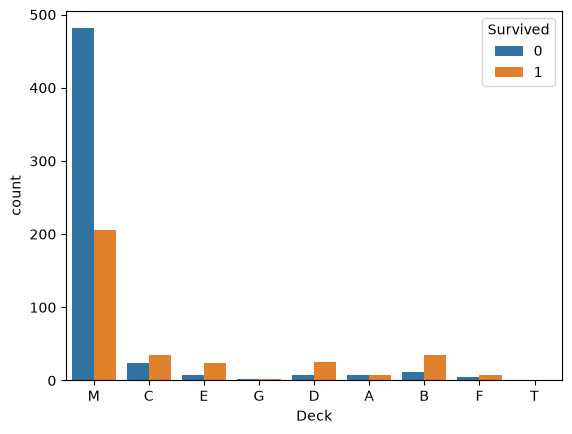

In [493]:
# 'M'으로 Deck를 채운게 실제 잘 된건지, 의미가 없을지, 문제가 없을지
sns.countplot(data=train, x='Deck', hue='Survived')
# countplot: 개수 시각화
# hue: 분할 기준
plt.show()

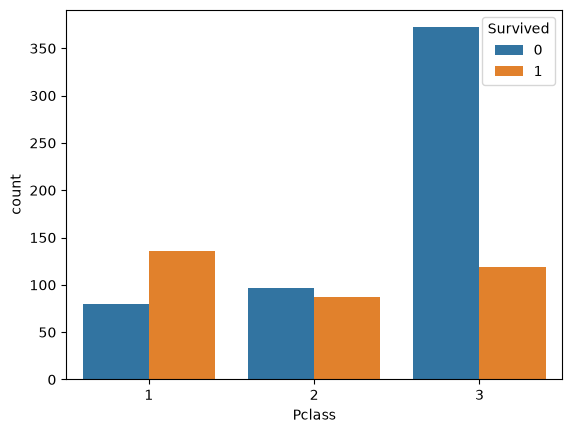

In [494]:
# Pclass와 사망에 얼마나 많은 영향을 주나?
sns.countplot(train, x='Pclass', hue='Survived')
plt.show()

In [495]:
# 1: 생존율이 제일 높다
# 2: 사망율이 좀 높지만 생존율과 비슷
# 3: 사망율이 굉장히 높다
##### 비싼 자리가 생존율이 높다

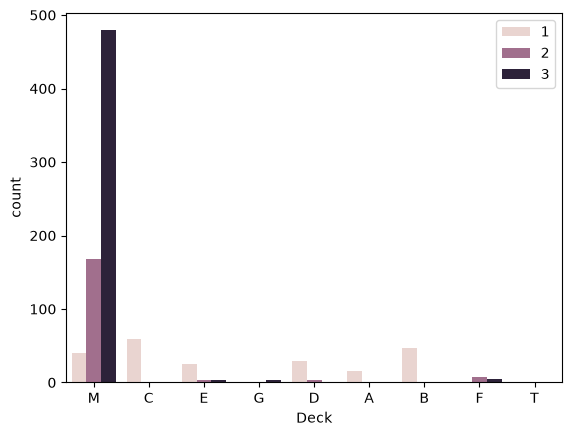

In [496]:
# Deck에 어떤 등급(Pclass) 사람이 많은지
sns.countplot(data=train, x='Deck',hue='Pclass')
plt.legend()
plt.show()

In [497]:
# 'M'층에는 3등급의 사람이 많다
# 상대적으로 사망율이 높은건 아닐까?
# 'M'이라는 데이터는 더이상 신경쓰지 않겠다... 3등급이 많아서 사망율이 높았을 것이다

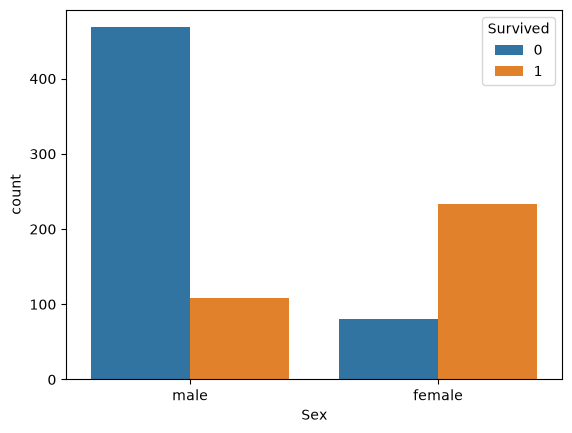

In [498]:
sns.countplot(data=train, x='Sex', hue='Survived')
plt.show()
# 남성 사망율이 높고, 여성 생존율이 상대적으로 높다

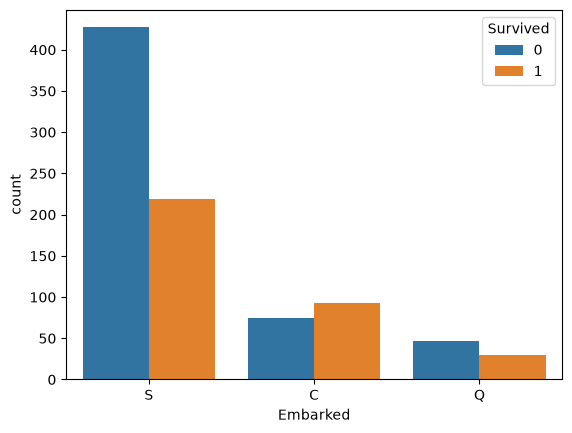

In [499]:
# 승선항(Embarked)별 생존/사망
sns.countplot(data=train, x='Embarked', hue='Survived')
plt.show()

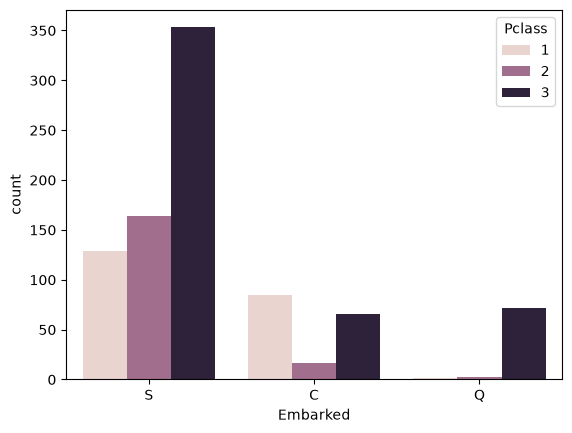

In [500]:
# S승선항에서 Pclass 3인 사람이 많이 탔나?
sns.countplot(data=train, x='Embarked', hue='Pclass')
plt.show()

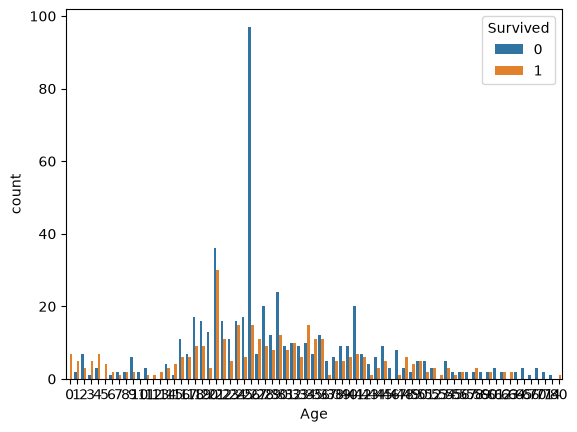

In [501]:
# Age, Survived 한 여부를 상관 관계를 시각화
sns.countplot(data=train, x='Age',hue='Survived')
plt.show()

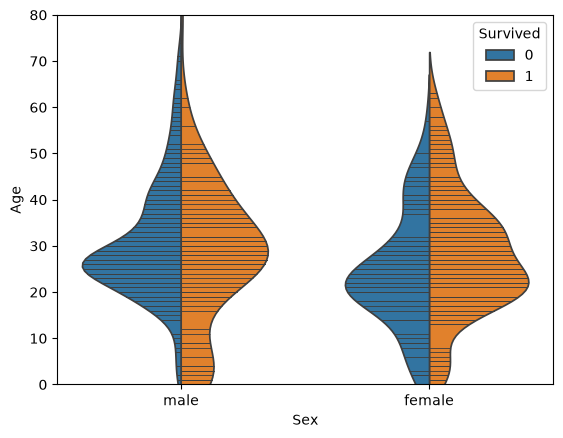

In [502]:
# countplot으로 볼 때 해석이 어려움
# violinplot 활용: 수치형 데이터 분포를 확인 할 때 사용하는 형태
# 바이올린 형태로 데이터의 분포와 밀도를 보기 좋게 곡선으로 처리한 그래프
sns.violinplot(
    data=train,
    x='Sex',
    y='Age',
    hue='Survived',
    split=True, # 성별로 나눈걸 둘로 나눠서 보기 위해
    inner='stick' #바이올린 내부에 개별 데이터선
)
plt.ylim(0,80)
plt.show()

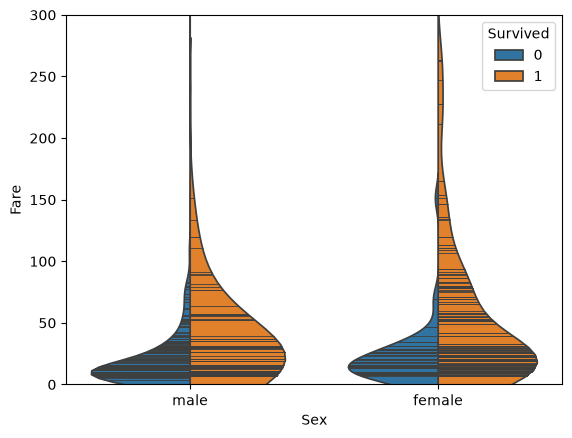

In [503]:
# 성별 - 요금(Fare) - 생존 관계 (violinplot)
sns.violinplot(
    data=train,
    x='Sex',
    y='Fare',
    hue='Survived',
    inner='stick',
    split=True
)
plt.ylim(0,300)
plt.show()

In [504]:
# 성별 불문하고 요금이 낮은 티켓의 사람이 사망율이 높다, 높은 사람은 생존율이 높다

## 4. 파생 변수 만들기 — Family_Size → Family_group

`SibSp + Parch + 1` 로 **가족 수**를 만들고, 이를 구간으로 묶어(**binning**) 범주형 `Family_group` 으로 만든다.

In [505]:
# Parch, SibSp → FamilySize
# 한 row(data)에 있는 숫자를 다 합치고 + 1 → 가족 구성원 수
train['Family_Size'] = train['Parch'] + train['SibSp'] + 1
train['Family_Size']

PassengerId
1      2
2      2
3      1
4      2
5      1
      ..
887    1
888    1
889    4
890    1
891    1
Name: Family_Size, Length: 891, dtype: int64

In [506]:
# test에도 동일하게 Family_Size 생성
test['Family_Size'] = test['Parch'] + test['SibSp'] + 1
test['Family_Size']

PassengerId
892     1
893     2
894     1
895     1
896     3
       ..
1305    1
1306    1
1307    1
1308    1
1309    3
Name: Family_Size, Length: 418, dtype: int64

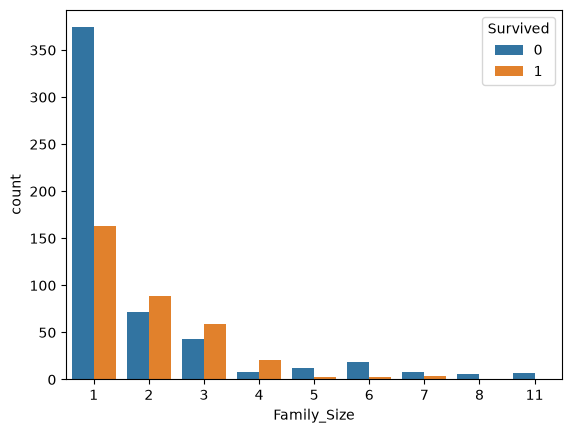

In [507]:
# Family_Size와 생존 연관도 시각화
sns.countplot(data=train, x='Family_Size',hue='Survived')
plt.show()

In [508]:
# 1명: 사망율이 높다         → 'alone'
# 2-4명: 생존율이 조금 높다   → 'small'
# 5명 이상: 사망율이 높다     → 'large'
# 수치형 데이터를 범주형 데이터로 'binning' 만들어서 항목의 수를 줄여보자
# binning을 통해서 생길수 있었던 사소한 EDA 할 때의 오류들을 줄여보자

In [509]:
labels = ['alone', 'small', 'large']
bins = [0, 1, 4, 11]
# (0,1],(1,4],(4,11] 
# (n,m] → n초과 m이하

# cut: 연속적인 수치형 데이터를 일정 범위로 나눠주는 → 범주형 데이터로 binning
train['Family_group'] = pd.cut(train['Family_Size'], bins=bins, labels=labels)
test['Family_group'] = pd.cut(test['Family_Size'], bins=bins, labels=labels)

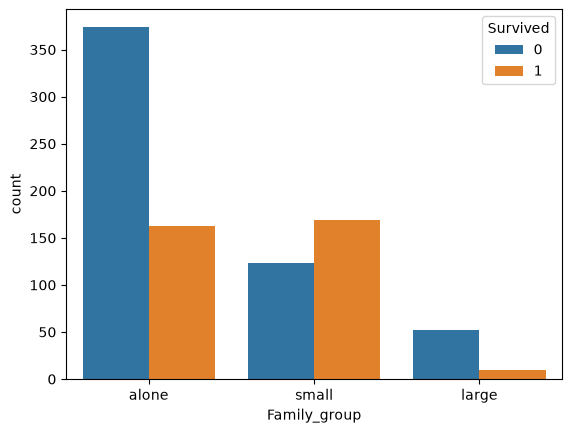

In [510]:
# Family_group별 생존/사망
sns.countplot(data=train, x='Family_group',hue='Survived')
plt.show()

In [511]:
# 현재 컬럼 상태 확인
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Survived      891 non-null    int64   
 1   Pclass        891 non-null    int64   
 2   Name          891 non-null    object  
 3   Sex           891 non-null    object  
 4   Age           891 non-null    int64   
 5   SibSp         891 non-null    int64   
 6   Parch         891 non-null    int64   
 7   Ticket        891 non-null    object  
 8   Fare          891 non-null    float64 
 9   Embarked      891 non-null    object  
 10  Deck          891 non-null    object  
 11  Family_Size   891 non-null    int64   
 12  Family_group  891 non-null    category
dtypes: category(1), float64(1), int64(6), object(5)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------      

## 5. 학습 데이터 준비 (컬럼 정리 · 인코딩)

In [512]:
# Name, Ticket, SibSp, Parch, Family_Size
train.drop(['Name','Ticket','SibSp','Parch','Family_Size'], axis=1, inplace=True)
test.drop(['Name','Ticket','SibSp','Parch','Family_Size'], axis=1, inplace=True)

In [513]:
# 남은 컬럼 확인
train.columns, test.columns

(Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Deck',
        'Family_group'],
       dtype='object'),
 Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Deck', 'Family_group'], dtype='object'))

In [514]:
## 결측치를 채우고 새로운 column을 만들어 비슷한 내용을 합치기까지 전처리 완료
## Train, Test, X, y 구분하기

X_train = train.drop('Survived', axis=1)
# train.iloc[:,1:], train[:,'Pclass':]
y_train = train['Survived']

X_test = test
# y_test = 우리가 맞춰야될 실험 (titanic 데이터셋에선 제공되지 않습니다.)

In [515]:
## 범주형 데이터를 수치형 데이터로 변환 (Encoding) 과정

X_train_one_hot = pd.get_dummies(X_train)
X_test_one_hot = pd.get_dummies(X_test)

In [516]:
# 원-핫 인코딩 결과 확인
X_train_one_hot

,Pclass,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_M,Deck_T,Family_group_alone,Family_group_small,Family_group_large
PassengerId,,,,,,,,,,,,,,,,,,,,
1,3,22,7.2500,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False
2,1,38,71.2833,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False
3,3,26,7.9250,True,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False
4,1,35,53.1000,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False
5,3,35,8.0500,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,2,27,13.0000,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False
888,1,19,30.0000,True,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
889,3,21,23.4500,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False


> ⚠️ **train / test 컬럼 맞추기**
>
> `get_dummies` 는 **데이터에 실제로 있는 값만** 컬럼으로 만든다.
> → train 엔 `Deck_T` 가 있는데 test 엔 없어서 컬럼 개수가 달라진다.
> → 없는 컬럼을 0으로 추가하고 **순서까지 train 기준으로 맞춰야** 모델 입력 오류가 안 난다.

In [517]:
# train, test 데이터셋의 차원을 맞춰야 모델 입력에 오류가 없다
# train에는 있으면 test에 없는건? 반대로 test에 있으면서 train에 없는건 어떤 column들이 있을까?

print(X_train_one_hot.columns)
print(X_test_one_hot.columns)

Index(['Pclass', 'Age', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D',
       'Deck_E', 'Deck_F', 'Deck_G', 'Deck_M', 'Deck_T', 'Family_group_alone',
       'Family_group_small', 'Family_group_large'],
      dtype='object')
Index(['Pclass', 'Age', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D',
       'Deck_E', 'Deck_F', 'Deck_G', 'Deck_M', 'Family_group_alone',
       'Family_group_small', 'Family_group_large'],
      dtype='object')


In [518]:
# 중복제거 한 두 dataframe의 컬럼 값들을 비교
set(X_train_one_hot) - set(X_test_one_hot)

{'Deck_T'}

In [519]:
# test엔 없는 Deck_T 컬럼을 0으로 추가 (train과 차원/컬럼 맞추기)
X_test_one_hot['Deck_T'] = 0
X_test_one_hot

,Pclass,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_M,Family_group_alone,Family_group_small,Family_group_large,Deck_T
PassengerId,,,,,,,,,,,,,,,,,,,,
892,3,34,7.8292,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False,0
893,3,47,7.0000,True,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,0
894,2,62,9.6875,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False,0
895,3,27,8.6625,False,True,False,False,True,False,False,False,False,False,False,False,True,True,False,False,0
896,3,22,12.2875,True,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,3,26,8.0500,False,True,False,False,True,False,False,False,False,False,False,False,True,True,False,False,0
1306,1,39,108.9000,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,0
1307,3,38,7.2500,False,True,False,False,True,False,False,False,False,False,False,False,True,True,False,False,0


In [520]:
# Train, Test의 Feature 순서 맞추기
X_test_one_hot = X_test_one_hot[X_train_one_hot.columns]

## 6. 모델 선택 및 학습 · 예측 · 평가

결정트리(Decision Tree)로 학습하고, **교차검증(cross-validation)** 으로 성능을 평가한다.
그다음 `max_depth`(트리 깊이)를 바꿔가며 가장 좋은 값을 찾는다.

In [521]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score # 교차 검증(cross-validation)

tree = DecisionTreeClassifier()
cv_result = cross_val_score(tree, X_train_one_hot, y_train, cv=5)
cv_result

array([0.72625698, 0.78651685, 0.83146067, 0.7752809 , 0.76966292])

In [522]:
# 교차검증 5개 점수의 평균 (모델의 대략적 성능)
cv_result.mean()

np.float64(0.777835666310966)

In [523]:
# max_depth를 조정해 가며(하이퍼파리머 조정) (1~9) 결과 비교
# tree = DecisionTreeClassifier(max_depth = ???)
for md in range(1,10):
    tree = DecisionTreeClassifier(max_depth = md)
    result = cross_val_score(tree, X_train_one_hot, y_train, cv=5)
    print(f'depth:{md}', result.mean())

depth:1 0.7867365513778168
depth:2 0.773316176009039


depth:3 0.8013370158809867
depth:4 0.8081288054736049
depth:5 0.8148201619484026
depth:6 0.815956311593748
depth:7 0.8170673529596384
depth:8 0.8181846713953927
depth:9 0.8081036971941498


In [524]:
# max_depth가 7일때 성능이 제일 높더라
tree_model = DecisionTreeClassifier(max_depth=7)
tree_model.fit(X_train_one_hot, y_train)
y_pred = tree_model.predict(X_test_one_hot)

result = pd.read_csv('./data/test.csv', index_col='PassengerId')
result['Survived'] = y_pred
result.to_csv('./tree_model_pred.csv', index=False)

In [525]:
# 각 Feature가 예측에 얼마나 기여했는지 (feature importance)
fe_im = tree_model.feature_importances_
fe_im

array([0.11944483, 0.1669573 , 0.11651233, 0.        , 0.46295846,
       0.00277925, 0.00243089, 0.        , 0.        , 0.        ,
       0.00372074, 0.        , 0.01391304, 0.        , 0.        ,
       0.05617682, 0.        , 0.        , 0.0302056 , 0.02490073])

In [526]:
# 중요도를 컬럼명과 함께 내림차순 정렬한 표
fi_s = pd.DataFrame(fe_im, index = X_train_one_hot.columns, columns=['중요도']).sort_values('중요도', ascending=False)

In [527]:
# 중요도 표 확인
fi_s

,중요도
Sex_male,0.462958
Age,0.166957
Pclass,0.119445
Fare,0.116512
Deck_M,0.056177
Family_group_small,0.030206
Family_group_large,0.024901
Deck_E,0.013913
Deck_C,0.003721
Embarked_C,0.002779


## 7. 앙상블(Ensemble) 모델

**앙상블** : 여러 개의 모델을 묶어 하나의 더 강한 모델을 만드는 방법.
> "한 명의 전문가보다 여러 명의 의견을 모으는 것이 더 정확하다"

| 방식 | 핵심 아이디어 | 대표 모델 |
| --- | --- | --- |
| **Voting** (투표) | 서로 **다른 모델**들의 예측을 모아서 결합 | `VotingClassifier` |
| **Bagging** (배깅) | **같은 모델**을 서로 다른 데이터 샘플로 여러 개 학습 → 투표 | `RandomForest` |
| **Boosting** (부스팅) | 모델을 **순차적으로** 학습하며 이전 모델의 오답을 보정 | `AdaBoost`, `GBM`, `XGBoost`, `LightGBM` |

In [ ]:
# ─────────────────────────────────────────────────────────────
# 앙상블(Ensemble)의 3가지 방식 : Voting, Bagging, Boosting
# ─────────────────────────────────────────────────────────────

# 1) Voting (투표) : 서로 '다른' 모델들의 예측을 모아 결합
#    - 하드보팅(hard) : 각 모델이 내놓은 결과(Y) 값들의 단순 과반수로 결정
#    - 소프트보팅(soft): 각 모델이 내놓은 '확률' 값들을 더해서 결정
#
#    예) Class1 : Class2 확률을 4개의 모델이 아래처럼 예측했다면
#        Model1 (6:4) / Model2 (6:4) / Model3 (1:9) / Model4 (6:4)
#        → 하드보팅  : Class 1  (3표 vs 1표)
#        → 소프트보팅 : Class 2  (0.6+0.6+0.1+0.6 = 1.9  vs  0.4+0.4+0.9+0.4 = 2.1)
#    → 확신이 아주 강한 모델(1:9)의 의견까지 반영되는 것이 소프트보팅

# 2) Bagging (배깅) : '같은' 모델을 여러 데이터 샘플에 대해 학습시키고 투표로 예측
#    - 대표 모델 : RandomForest (결정트리 여러 개를 모아놓은 '숲')

# 3) Boosting (부스팅) : 여러 모델을 '순차적으로' 학습 (이전 모델의 오류를 보정)
#    - 대표 모델 : AdaBoost, GBM, XGBoost, LightGBM
#    - 후속 모델이 이전 모델의 잘못된 예측을 집중 학습해 성능이 점차 좋아진다

In [528]:
# 앙상블 모델들 불러오기 (모두 sklearn.ensemble 안에 있다)
from sklearn.ensemble import VotingClassifier      # Voting  : 다른 모델들을 투표로 결합
from sklearn.ensemble import RandomForestClassifier # Bagging : 결정트리 여러 개(숲)
from sklearn.ensemble import AdaBoostClassifier     # Boosting: 오답에 가중치를 주며 순차 학습
from sklearn.ensemble import GradientBoostingClassifier # Boosting: 오차(잔차)를 줄여가며 순차 학습

### 7-1. Bagging — RandomForest

**RandomForest** : 결정트리(Decision Tree) 여러 개를 만들어 **투표**로 최종 결과를 정하는 모델.
트리마다 서로 다른 데이터·Feature를 보게 해서, 트리 하나일 때보다 **과대적합이 줄고 성능이 안정적**이다.

In [529]:
# RandomForest = 결정트리 여러 개를 만들어 그 결과를 투표로 결정하는 모델 (Bagging)
# n_estimators=100 : 만들 트리(모델)의 개수 → 많을수록 안정적이지만 느려진다
# max_features=5   : 트리 하나가 사용할 Feature 개수 → 트리마다 다른 특징을 보게 해 다양성 확보
# max_depth=4      : 트리 하나의 최대 깊이 → 과대적합(overfitting) 방지
# random_state=11  : 난수 고정 → 실행할 때마다 같은 결과가 나오도록
forest = RandomForestClassifier(n_estimators=100, max_features=5, max_depth=4,random_state=11)

In [530]:
# 교차검증(cv=5)으로 RandomForest 성능 확인 → 5개 점수의 평균
result_rf = cross_val_score(forest, X_train_one_hot, y_train,cv=5)
result_rf.mean()

np.float64(0.8159312033142928)

### 7-2. Boosting — AdaBoost

**AdaBoost(Adaptive Boosting)** : 약한 모델을 순차적으로 학습시키되,
**앞 모델이 틀린 데이터에 더 큰 가중치**를 줘서 다음 모델이 그 부분을 집중적으로 학습하게 한다.

In [533]:
# AdaBoost 모델 생성
# n_estimators=100 : 순차적으로 학습시킬 약한 모델(weak learner)의 개수
# random_state=0   : 난수 고정
ada = AdaBoostClassifier(n_estimators=100, random_state=0)

In [534]:
# 교차검증으로 AdaBoost 성능 확인
result_ada = cross_val_score(ada, X_train_one_hot, y_train, cv=5)
result_ada.mean()

np.float64(0.8092398468394952)

### 7-3. Voting — 여러 모델을 묶어 투표

앞에서 만든 **결정트리 · 랜덤포레스트 · 에이다부스트** 3개를 하나로 묶는다.
`voting='soft'` → 각 모델이 예측한 **확률을 더해서** 최종 결정 (소프트보팅)

In [537]:
# estimators : ('이름', 모델) 형태로 묶어줄 모델들을 나열
# voting='soft' : 확률 값을 더해서 결정 (predict_proba 를 지원하는 모델만 가능)
#          'hard' 로 주면 다수결(과반수) 방식
voting = VotingClassifier(estimators=[('tree',tree),('forest',forest),('ada',ada)],
                          voting='soft')

In [539]:
# 교차검증으로 Voting 앙상블 성능 확인
result_vote = cross_val_score(voting, X_train_one_hot, y_train, cv=5)
result_vote.mean()

np.float64(0.8125792480070302)

### 7-4. Boosting — XGBoost & LightGBM

sklearn에 들어있지 않은 **외부 부스팅 라이브러리**. 캐글에서 가장 많이 쓰이는 모델들이다.

- **XGBoost** : GBM을 빠르고 정교하게 개선한 모델 (규제 기능 추가)
- **LightGBM** : XGBoost보다 더 빠르고 메모리를 적게 쓰는 모델 (대용량 데이터에 유리)

> 💡 아래 `pip install` 은 **처음 한 번만** 실행하면 된다. (이미 설치했다면 건너뛰기)

In [540]:
pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 660.6 kB/s eta 0:02:34
   ---------------------------------------- 0.3/101.7 MB 3.4 MB/s eta 0:00:30
   ---------------------------------------- 0.7/101.7 MB 5.7 MB/s eta 0:00:18
    --------------------------------------- 1.3/101.7 MB 7.5 MB/s eta 0:00:14
    --------------------------------------- 2.0/101.7 MB 9.0 MB/s eta 0:00:12
   - -------------------------------------- 2.9/101.7 MB 10.8 MB/s eta 0:00:10
   - -------------------------------------- 4.0/101.7 MB 12.7 MB/s eta 0:00:08
   -- ------------------------------------- 5.3/101.7 MB 14.9 MB/s eta 0:00:07
   -- ------------------------------------- 5.4/101.7 MB 15.0 MB/s eta 0:00:07
   -- ----------


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [541]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [542]:
# 설치한 라이브러리에서 분류(Classifier) 모델 불러오기
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [544]:
# XGBoost 모델 생성
# ⚠️ n_estimatos → n_estimators 오타! (이름이 틀려서 실제로는 기본값이 적용된다)
xg = XGBClassifier(n_estimatos=100, random_state=13)

# XGBoost는 정답(y)이 정수형이어야 하므로 int64로 변환
y_train = y_train.astype('int64')

In [546]:
# 교차검증으로 XGBoost 성능 확인
result_xg = cross_val_score(xg, X_train_one_hot, y_train, cv=5)
result_xg.mean()

c:\Users\smhrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:06:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimatos" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\smhrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:06:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimatos" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\smhrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:06:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimatos" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\smhrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:06:12] WARNING: C:\actions-runner\_work\xg

np.float64(0.8114682066411399)

In [549]:
# LightGBM 모델 생성 후 바로 교차검증
# n_estimators=100 : 순차적으로 만들 트리 개수
lgb = LGBMClassifier(n_estimators=100, random_state=55)
result_lgb = cross_val_score(lgb, X_train_one_hot, y_train, cv=5)
result_lgb.mean()

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

np.float64(0.8260686711443098)

### ✅ 앙상블 모델 성능 비교 정리

| 모델 | 변수 | 방식 |
| --- | --- | --- |
| Decision Tree | `cv_result` | 단일 트리 (기준점) |
| RandomForest | `result_rf` | Bagging |
| AdaBoost | `result_ada` | Boosting |
| Voting (soft) | `result_vote` | Voting |
| XGBoost | `result_xg` | Boosting |
| LightGBM | `result_lgb` | Boosting |

각 셀의 `.mean()` 값을 비교해서 **가장 점수가 높은 모델**을 고르면 된다.

## 8. Grid Search — 최적의 하이퍼파라미터 찾기

**하이퍼파라미터** : `max_depth`, `n_estimators` 처럼 **사람이 직접 정해줘야 하는 값**.
앞에서는 `for` 문을 돌려 하나씩 눈으로 비교했지만,
**GridSearchCV** 는 후보 값들의 **모든 조합**을 자동으로 학습·교차검증해서 **가장 좋은 조합**을 찾아준다.

In [558]:
# GridSearchCV 불러오기 (아래 셀에서 다시 import 하므로 사실 중복 실행)
from sklearn.model_selection import GridSearchCV

In [559]:
from sklearn.model_selection import GridSearchCV

# Random Forest Grid Search
# 1. Hyper Parameter 경우의 수를 미리 설정 (딕셔너리 = {'파라미터명' : [후보 값들]})
params = {
    'n_estimators': [50, 100, 200],      # 트리 개수
    'max_depth': [3, 5, 7],              # 트리 최대 깊이
    'min_samples_split': [3, 5, 7]       # 노드를 분할하기 위한 최소 샘플 수
}
# 원래대로라면 n_estimators, max_depth, min_samples_split 조합으로 3^3 = 27번 시도하고 결과를 눈으로 비교
# Grid Search 이용해서 최적의 parameter 값을 도출 할 수 있다.

# 2. 모델 초기화
rf_clf = RandomForestClassifier(random_state=24)
# 모든 hyper parameter 들에 대해서 같은 결과를 보기 위해 난수를 고정

# 3. gridsearch 옵션을 설정하고 비교하게 한다
grid = GridSearchCV(
    rf_clf,       # 튜닝할 모델
    params,       # 위에서 정한 하이퍼파라미터 후보들
    cv = 5,       # 교차검증 5번 → 총 27조합 x 5 = 135번 학습
    n_jobs = -1 # 병렬 처리 하도록 (사용 가능한 모든 CPU 코어를 사용하여 병렬 처리 하도록)
)
# ※ 아직 '설정'만 한 상태 → grid.fit(X_train_one_hot, y_train) 을 실행해야 실제로 탐색이 시작된다
#    학습 후 grid.best_params_ (최적 조합), grid.best_score_ (그때의 점수) 로 결과를 확인

In [561]:
grid.fit(X_train_one_hot, y_train)

grid.best_params_

{'max_depth': 7, 'min_samples_split': 7, 'n_estimators': 50}

In [562]:
grid.best_score_

best_rf_clf = grid.best_estimator_

cross_val_score(best_rf_clf, X_train_one_hot, y_train, cv=5).mean()

np.float64(0.8294080723118448)

In [565]:
from sklearn.model_selection import train_test_split

# Titanic Dataset
data = pd.read_csv('./data/train.csv')
d = data.copy() # 복사본
d['Age'] = d['Age'].fillna(d['Age'].median()) # 중앙값으로 나이 채우기
d['Embarked'] = d['Embarked'].fillna(d['Embarked'].mode()[0]) # 승강장 값 채우기
d['Sex'] = (d['Sex']=='male').astype(int) # 성별을 'male'을 조건으로 걸어 숫자로 바꾸기
d = pd.get_dummies(d, columns=['Embarked']) # 승강장 S,C,Q를 one-hot encoding
feats = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked_C','Embarked_Q','Embarked_S'] # → Cabin, Name, Ticket
X = d[feats]; y = d['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=8, stratify=y)
print('train', X_train.shape, '| test', X_test.shape)

train (623, 9) | test (268, 9)


In [566]:
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

print('OOB: ',round(rf.oob_score_,4),'← 검증 없이 OOB로 뽑은 성능')
print('실제: ', round(rf.score(X_test,y_test),4))

# 결론적으론 OOB로 뽑은 성능과 실제 성능이 비슷하면, OOB가 대용품이 될 수 있다!

OOB:  0.7929 ← 검증 없이 OOB로 뽑은 성능
실제:  0.8358


In [569]:
# n_estimators(트리 개수)를 늘려가며 OOB 점수가 어디서 더 이상 안 오르고 비슷해지는지 확인하기
import time   # ← 'time'을 변수명으로 쓰면 모듈이 가려지니 주의! (리스트는 times 로)

n_list = [5, 10, 25, 50, 100, 200, 400]
oob_scores, test_scores, times = [], [], []

for n in n_list:
    t0 = time.time()   # 학습 시작 시간
    # oob_score=True : 학습에 쓰이지 않고 남은 데이터(Out Of Bag)로 스스로 성능을 매긴다
    m = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=0, n_jobs=-1).fit(X_train, y_train)
    times.append(time.time() - t0)          # 학습에 걸린 시간
    oob_scores.append(m.oob_score_)         # OOB 점수
    test_scores.append(m.score(X_test, y_test))   # 실제 test 점수
    print(f'n_estimators={n:>4} | OOB {m.oob_score_:.4f} | test {test_scores[-1]:.4f} | {times[-1]:.2f}초')

# 트리 개수가 늘수록 OOB 점수는 오르다가 어느 지점부터 거의 평평해진다(수렴)
# → 그 지점 이후로는 시간만 더 걸리고 성능은 그대로 → 적당한 n_estimators를 고르면 된다

c:\Users\smhrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\smhrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n_estimators=   5 | OOB 0.7480 | test 0.8172 | 0.03초
n_estimators=  10 | OOB 0.7721 | test 0.7985 | 0.03초
n_estimators=  25 | OOB 0.7624 | test 0.8097 | 0.05초
n_estimators=  50 | OOB 0.7881 | test 0.8284 | 0.08초
n_estimators= 100 | OOB 0.7929 | test 0.8358 | 0.21초
n_estimators= 200 | OOB 0.7913 | test 0.8396 | 0.24초
n_estimators= 400 | OOB 0.7945 | test 0.8321 | 0.45초


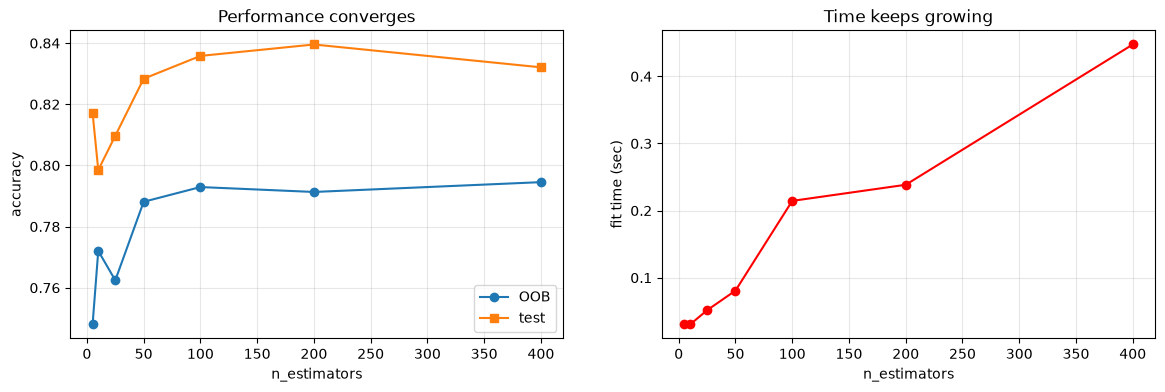

In [570]:
fig, ax = plt.subplots(1,2, figsize=(14,4))
ax[0].plot(n_list, oob_scores, 'o-', label='OOB')
ax[0].plot(n_list, test_scores, 's-', label='test')
ax[0].set_xlabel('n_estimators'); ax[0].set_ylabel('accuracy'); ax[0].legend()
ax[0].set_title('Performance converges'); ax[0].grid(alpha=0.3)
ax[1].plot(n_list, times, 'o-', color='red')
ax[1].set_xlabel('n_estimators'); ax[1].set_ylabel('fit time (sec)')
ax[1].set_title('Time keeps growing'); ax[1].grid(alpha=0.3)
plt.show()